# Autoencoder-Based Network Intrusion Detection on NSL-KDD

**AI for Cybersecurity, Module 3 Lab** · Ruthvik Nath Bandari · Northeastern University

This notebook builds an **unsupervised anomaly detector**: a small dense autoencoder is trained to
reconstruct *normal* network connections only. Anything it reconstructs badly is flagged as an
attack. Because the model never sees an attack during training, it can in principle catch attack
types nobody has labelled yet, which is the main reason anomaly detection matters in a SOC.

| Step | What happens |
|---|---|
| 1. Data | Load NSL-KDD, keep numerical features, train on normal traffic only, 80/20 train/validation split, StandardScaler |
| 2. Model | Autoencoder `n → 20 → 10 → 20 → n`, Adam + MSE, 50 epochs with early stopping, threshold = 95th percentile of training error |
| 3. Evaluation | Classification report, confusion matrix, ROC curve, Isolation Forest baseline, per-attack-type analysis |

**Dataset.** NSL-KDD (Tavallaee et al., 2009), the cleaned version of the KDD Cup 1999 data derived
from the DARPA/MIT Lincoln Laboratory intrusion detection evaluation. Official page:
<https://www.unb.ca/cic/datasets/nsl.html>. The files are identical to the UNB release; the cell
below downloads them from a public mirror so the notebook runs on Colab with *Runtime → Run all*.

In [1]:
import os, time, urllib.request
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"     # hide TensorFlow C++ info/warning logs
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, roc_auc_score,
                             average_precision_score, precision_recall_fscore_support)

SEED = 42
keras.utils.set_random_seed(SEED)          # seeds Python, NumPy and TensorFlow
tf.config.experimental.enable_op_determinism()

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_colwidth", None)
print("TensorFlow", tf.__version__)

TensorFlow 2.21.0


## Step 1 · Data loading and preprocessing

### 1.1 Load the data
NSL-KDD ships as headerless CSV files: 41 features, the attack label, and a difficulty score
(how many of 21 reference classifiers got the record wrong). `KDDTrain+` is the training set and
`KDDTest+` is the official test set, which deliberately includes **17 attack types that never
appear in training**. That makes it a good test of whether an anomaly detector generalises.

In [2]:
DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)
MIRROR = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/"
for fname in ["KDDTrain+.txt", "KDDTest+.txt"]:
    if not (DATA_DIR / fname).exists():
        urllib.request.urlretrieve(MIRROR + fname, DATA_DIR / fname)

COLUMNS = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land",
    "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in", "num_compromised",
    "root_shell", "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty",
]
train_df = pd.read_csv(DATA_DIR / "KDDTrain+.txt", names=COLUMNS)
test_df  = pd.read_csv(DATA_DIR / "KDDTest+.txt",  names=COLUMNS)

print(f"Train: {train_df.shape[0]:,} rows x {train_df.shape[1]} cols")
print(f"Test : {test_df.shape[0]:,} rows x {test_df.shape[1]} cols")
print("Missing values (train, test):", train_df.isna().sum().sum(), test_df.isna().sum().sum())
train_df.head()

Train: 125,973 rows x 43 cols
Test : 22,544 rows x 43 cols
Missing values (train, test): 0 0


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.1700,0.0300,0.1700,0.0000,0.0000,0.0000,0.0500,0.0000,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.0000,0.6000,0.8800,0.0000,0.0000,0.0000,0.0000,0.0000,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.1000,0.0500,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.0000,0.0000,0.0300,0.0400,0.0300,0.0100,0.0000,0.0100,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,normal,21


### 1.2 Map attack labels to the four standard categories
Each specific attack belongs to one of the four families used throughout the KDD literature:
**DoS** (denial of service), **Probe** (scanning), **R2L** (remote-to-local, i.e. unauthorised access
from a remote machine) and **U2R** (user-to-root privilege escalation). The mapping covers the
test-only attacks as well.

In [3]:
ATTACK_CATEGORY = {
    # DoS
    "back": "DoS", "land": "DoS", "neptune": "DoS", "pod": "DoS", "smurf": "DoS",
    "teardrop": "DoS", "apache2": "DoS", "mailbomb": "DoS", "processtable": "DoS", "udpstorm": "DoS",
    # Probe
    "ipsweep": "Probe", "nmap": "Probe", "portsweep": "Probe", "satan": "Probe",
    "mscan": "Probe", "saint": "Probe",
    # R2L
    "ftp_write": "R2L", "guess_passwd": "R2L", "imap": "R2L", "multihop": "R2L", "phf": "R2L",
    "spy": "R2L", "warezclient": "R2L", "warezmaster": "R2L", "sendmail": "R2L", "named": "R2L",
    "snmpgetattack": "R2L", "snmpguess": "R2L", "xlock": "R2L", "xsnoop": "R2L", "worm": "R2L",
    # U2R
    "buffer_overflow": "U2R", "loadmodule": "U2R", "perl": "U2R", "rootkit": "U2R",
    "httptunnel": "U2R", "ps": "U2R", "sqlattack": "U2R", "xterm": "U2R",
}
for df in (train_df, test_df):
    df["category"] = df["label"].map(ATTACK_CATEGORY).fillna("Normal")
    df.loc[df["label"] == "normal", "category"] = "Normal"
    df["is_attack"] = (df["label"] != "normal").astype(int)

unmapped = set(test_df.loc[test_df["label"] != "normal", "label"]) - set(ATTACK_CATEGORY)
assert not unmapped, f"Unmapped labels: {unmapped}"

counts = pd.DataFrame({"train": train_df["category"].value_counts(),
                       "test": test_df["category"].value_counts()}).fillna(0).astype(int)
counts.loc["Total"] = counts.sum()
novel = sorted(set(test_df["label"]) - set(train_df["label"]))
print(f"Attack types in test but never in training ({len(novel)}): {', '.join(novel)}")
counts

Attack types in test but never in training (17): apache2, httptunnel, mailbomb, mscan, named, processtable, ps, saint, sendmail, snmpgetattack, snmpguess, sqlattack, udpstorm, worm, xlock, xsnoop, xterm

,train,test
category,,
DoS,45927,7458
Normal,67343,9711
Probe,11656,2421
R2L,995,2754
U2R,52,200
Total,125973,22544


### 1.3 Feature selection: numerical features only
The brief asks for numerical features only. Of the 41 NSL-KDD features, three are categorical
strings (`protocol_type`, `service`, `flag`) and are dropped. One more, `num_outbound_cmds`, is
zero in every training record, so it carries no information and is dropped as well. That leaves
**37 numerical features**, so the autoencoder's input and output layers have 37 units rather than
41 (the brief's "41" is the full NSL-KDD feature count, including the categorical columns).

In [4]:
CATEGORICAL = ["protocol_type", "service", "flag"]
META = ["label", "difficulty", "category", "is_attack"]
numeric = [c for c in COLUMNS if c not in CATEGORICAL + META]
constant = [c for c in numeric if train_df[c].nunique() == 1]
FEATURES = [c for c in numeric if c not in constant]

print(f"41 features -> drop {len(CATEGORICAL)} categorical -> {len(numeric)} numerical "
      f"-> drop constant {constant} -> {len(FEATURES)} used")
train_df[FEATURES].describe().T[["mean", "std", "min", "50%", "max"]].head(12)

41 features -> drop 3 categorical -> 38 numerical -> drop constant ['num_outbound_cmds'] -> 37 used


,mean,std,min,50%,max
duration,287.1447,2604.5153,0.0000,0.0000,42908.0000
src_bytes,45566.7430,5870331.1819,0.0000,44.0000,1379963888.0000
dst_bytes,19779.1144,4021269.1514,0.0000,0.0000,1309937401.0000
land,0.0002,0.0141,0.0000,0.0000,1.0000
wrong_fragment,0.0227,0.2535,0.0000,0.0000,3.0000
urgent,0.0001,0.0144,0.0000,0.0000,3.0000
hot,0.2044,2.1500,0.0000,0.0000,77.0000
num_failed_logins,0.0012,0.0452,0.0000,0.0000,5.0000
logged_in,0.3957,0.4890,0.0000,0.0000,1.0000
num_compromised,0.2793,23.9420,0.0000,0.0000,7479.0000


### 1.4 Handle heavy-tailed features
`src_bytes` has a median of 44 but a maximum above a billion. StandardScaler divides by the
standard deviation, which such outliers inflate enormously, so almost every normal record would
be squashed to about 0 and the model could not learn useful structure. A `log1p` transform is applied
first to every non-negative count or byte feature whose maximum exceeds 1 (rates and binary flags
are already in [0, 1] and are left alone). StandardScaler is still the normaliser; `log1p` only
makes its mean and standard deviation meaningful. Section 2.6 checks that this helps.

In [5]:
LOG_COLS = [c for c in FEATURES if train_df[c].max() > 1]
print(f"log1p applied to {len(LOG_COLS)} features: {LOG_COLS}")

def to_matrix(df, log=True):
    X = df[FEATURES].astype("float64").copy()
    if log:
        X[LOG_COLS] = np.log1p(X[LOG_COLS])
    return X.values

skew_before = train_df[LOG_COLS].skew().abs().mean()
skew_after = pd.DataFrame(to_matrix(train_df), columns=FEATURES)[LOG_COLS].skew().abs().mean()
print(f"Mean |skew| of those features: {skew_before:.1f} -> {skew_after:.1f}")

log1p applied to 17 features: ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'count', 'srv_count', 'dst_host_count', 'dst_host_srv_count']
Mean |skew| of those features: 83.4 -> 23.8


### 1.5 Normal-only training data, 80/20 split, standardisation
Only `normal` training records are used to fit the model. They are split 80% train / 20%
validation first, and the scaler is then fitted on the 80% training portion only. Fitting the scaler on
the full set before splitting would leak validation statistics into training. Validation data is
used for early stopping and for checking the false-positive rate of the threshold.

The test set is the full `KDDTest+` file (normal plus all four attack categories), transformed with the
**same** scaler fitted on normal training data.

In [6]:
normal_train = train_df[train_df["is_attack"] == 0]
X_normal = to_matrix(normal_train)
X_tr_raw, X_val_raw = train_test_split(X_normal, test_size=0.20, random_state=SEED, shuffle=True)

scaler = StandardScaler().fit(X_tr_raw)
X_train = scaler.transform(X_tr_raw).astype("float32")
X_val   = scaler.transform(X_val_raw).astype("float32")
X_test  = scaler.transform(to_matrix(test_df)).astype("float32")
y_test  = test_df["is_attack"].values
cat_test = test_df["category"].values

print(f"Normal training records: {len(X_normal):,}  (attacks excluded: {train_df['is_attack'].sum():,})")
print(f"  train      : {X_train.shape}")
print(f"  validation : {X_val.shape}")
print(f"Test (mixed) : {X_test.shape}  normal={int((y_test==0).sum()):,}  attack={int(y_test.sum()):,}")
print(f"Scaled train mean ~ {X_train.mean():.3f}, std ~ {X_train.std():.3f}")

Normal training records: 67,343  (attacks excluded: 58,630)
  train      : (53874, 37)
  validation : (13469, 37)
Test (mixed) : (22544, 37)  normal=9,711  attack=12,833
Scaled train mean ~ -0.000, std ~ 0.986


## Step 2 · Autoencoder implementation

### 2.1 Architecture
Input (37) → Dense(20, ReLU) → **Dense(10, ReLU) bottleneck** → Dense(20, ReLU) → Output(37, linear).
The 10-unit bottleneck forces the network to learn a compressed description of *normal*
behaviour. The output is linear because standardised features can be negative.

In [7]:
N_FEATURES = X_train.shape[1]

def build_autoencoder(n_features):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(20, activation="relu", name="encoder_1"),
        layers.Dense(10, activation="relu", name="bottleneck"),
        layers.Dense(20, activation="relu", name="decoder_1"),
        layers.Dense(n_features, activation="linear", name="reconstruction"),
    ], name="nslkdd_autoencoder")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model

autoencoder = build_autoencoder(N_FEATURES)
autoencoder.summary()

Model: "nslkdd_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_1 (Dense)               │ (None, 20)             │           760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Dense)               │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 37)             │           777 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,967 (7.68 KB)

 Trainable params: 1,967 (7.68 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Train on normal traffic only
Up to 50 epochs, batch size 256. The input is also the target. Early stopping watches validation loss
with a patience of 5 epochs and restores the best weights, so the model is not over-fitted to the
training records.

In [8]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                           restore_best_weights=True, verbose=1)
t0 = time.time()
history = autoencoder.fit(X_train, X_train,
                          validation_data=(X_val, X_val),
                          epochs=50, batch_size=256, shuffle=True,
                          callbacks=[early_stop], verbose=2)
hist = pd.DataFrame(history.history)
best_epoch = int(hist["val_loss"].idxmin()) + 1
print(f"\nTrained {len(hist)} epochs in {time.time()-t0:.0f}s; best epoch {best_epoch} "
      f"(val MSE {hist['val_loss'].min():.4f}); train MSE fell {hist['loss'].iloc[0]:.4f} -> {hist['loss'].iloc[-1]:.4f}")

Epoch 1/50


211/211 - 1s - 3ms/step - loss: 0.7860 - val_loss: 0.5303


Epoch 2/50


211/211 - 0s - 429us/step - loss: 0.5025 - val_loss: 0.3941


Epoch 3/50


...

211/211 - 0s - 420us/step - loss: 0.1352 - val_loss: 0.1371


Epoch 50/50


211/211 - 0s - 417us/step - loss: 0.1345 - val_loss: 0.1355


Restoring model weights from the end of the best epoch: 50.



Trained 50 epochs in 5s; best epoch 50 (val MSE 0.1355); train MSE fell 0.7860 -> 0.1345


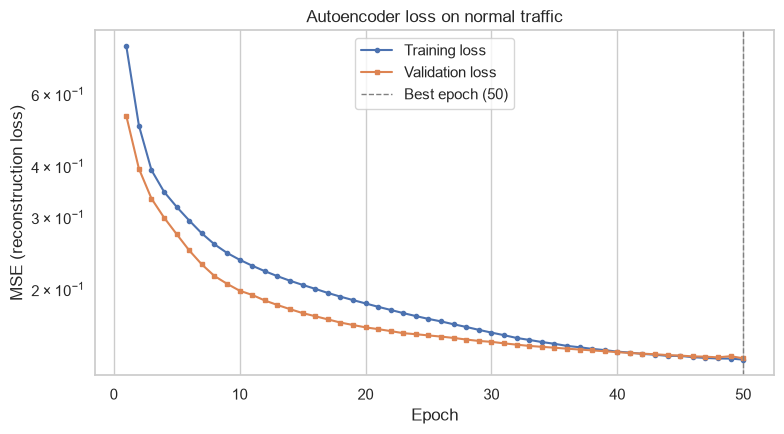

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
epochs = np.arange(1, len(hist) + 1)
ax.plot(epochs, hist["loss"], marker="o", ms=3, label="Training loss")
ax.plot(epochs, hist["val_loss"], marker="s", ms=3, label="Validation loss")
ax.axvline(best_epoch, color="grey", ls="--", lw=1, label=f"Best epoch ({best_epoch})")
ax.set(xlabel="Epoch", ylabel="MSE (reconstruction loss)", yscale="log",
       title="Autoencoder loss on normal traffic")
ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "fig1_loss_curve.png", dpi=200); plt.show()

### 2.3 Reconstruction-error threshold
The anomaly score of a record is its mean squared reconstruction error across the 37 features. Following the
brief, the threshold is the **95th percentile of training-set errors**, meaning 5% of the normal
training traffic would be flagged by design. The validation set, which the threshold never saw, checks
that this false-positive rate holds on unseen normal data.

In [10]:
def reconstruction_error(model, X):
    recon = model.predict(X, batch_size=2048, verbose=0)
    return np.mean(np.square(X - recon), axis=1)

err_train = reconstruction_error(autoencoder, X_train)
err_val   = reconstruction_error(autoencoder, X_val)
err_test  = reconstruction_error(autoencoder, X_test)

THRESHOLD = np.percentile(err_train, 95)
print(f"Threshold (95th pct of training error): {THRESHOLD:.4f}")
print(f"Flagged: train {np.mean(err_train > THRESHOLD):.2%} | validation {np.mean(err_val > THRESHOLD):.2%} (normal data)")

Threshold (95th pct of training error): 0.4961
Flagged: train 5.00% | validation 5.05% (normal data)


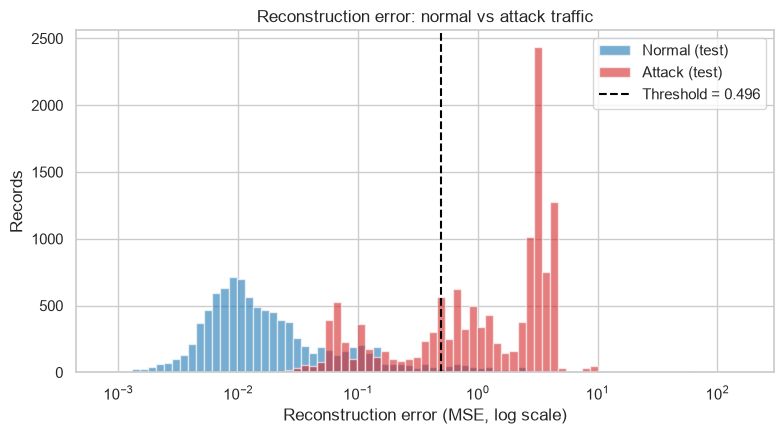

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.logspace(np.log10(max(err_test.min(), 1e-4)), np.log10(err_test.max()), 80)
ax.hist(err_test[y_test == 0], bins=bins, alpha=0.6, label="Normal (test)", color="tab:blue")
ax.hist(err_test[y_test == 1], bins=bins, alpha=0.6, label="Attack (test)", color="tab:red")
ax.axvline(THRESHOLD, color="black", ls="--", label=f"Threshold = {THRESHOLD:.3f}")
ax.set(xscale="log", xlabel="Reconstruction error (MSE, log scale)", ylabel="Records",
       title="Reconstruction error: normal vs attack traffic")
ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "fig2_error_distribution.png", dpi=200); plt.show()

### 2.4 Classify the mixed test set
Records with an error above the threshold are labelled **attack**.

In [12]:
y_pred_ae = (err_test > THRESHOLD).astype(int)
print(f"Flagged {y_pred_ae.sum():,} of {len(y_pred_ae):,} test records as anomalous")

Flagged 9,876 of 22,544 test records as anomalous


## Step 3 · Evaluation and analysis

### 3.1 Classification report

In [13]:
print("Autoencoder, threshold = 95th percentile of training error\n")
print(classification_report(y_test, y_pred_ae, target_names=["Normal", "Attack"], digits=4))

def summarise(name, y_true, y_pred, scores):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label=1)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {"model": name, "precision": p, "recall": r, "f1": f,
            "false_pos_rate": fp / (fp + tn), "accuracy": (tp + tn) / len(y_true),
            "roc_auc": roc_auc_score(y_true, scores), "pr_auc": average_precision_score(y_true, scores)}

ae_summary = summarise("Autoencoder", y_test, y_pred_ae, err_test)
pd.Series(ae_summary)

Autoencoder, threshold = 95th percentile of training error

              precision    recall  f1-score   support

      Normal     0.7336    0.9570    0.8305      9711
      Attack     0.9577    0.7370    0.8330     12833

    accuracy                         0.8318     22544
   macro avg     0.8456    0.8470    0.8317     22544
weighted avg     0.8611    0.8318    0.8319     22544



model             Autoencoder
precision              0.9577
recall                 0.7370
f1                     0.8330
false_pos_rate         0.0430
accuracy               0.8318
roc_auc                0.9582
pr_auc                 0.9582
dtype: object

### 3.2 Confusion matrix and ROC curve

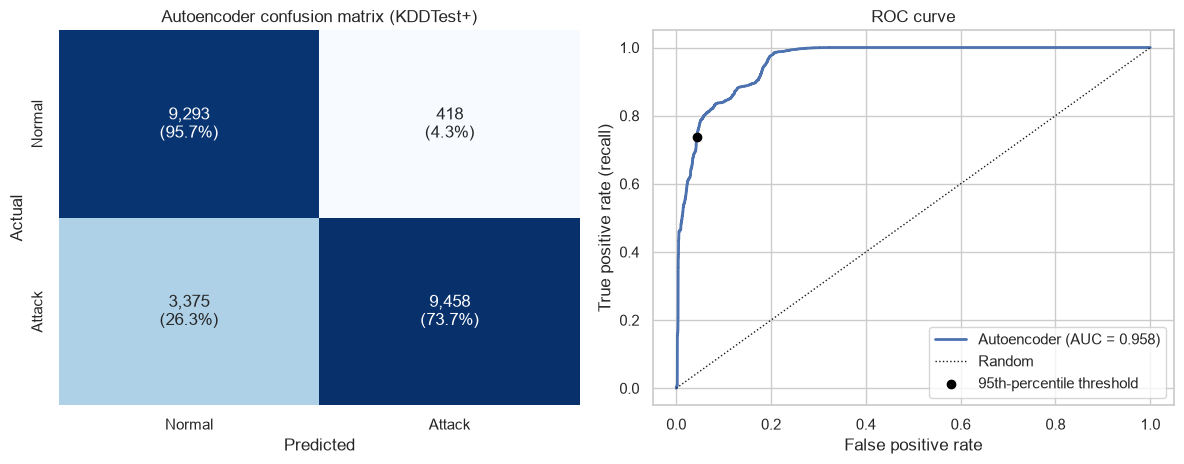

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
cm = confusion_matrix(y_test, y_pred_ae)
cm_pct = cm / cm.sum(axis=1, keepdims=True)
annot = np.array([[f"{cm[i, j]:,}\n({cm_pct[i, j]:.1%})" for j in range(2)] for i in range(2)])
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
axes[0].set(xlabel="Predicted", ylabel="Actual", title="Autoencoder confusion matrix (KDDTest+)")

fpr, tpr, _ = roc_curve(y_test, err_test)
op_fpr, op_tpr = ae_summary["false_pos_rate"], ae_summary["recall"]
axes[1].plot(fpr, tpr, lw=2, label=f"Autoencoder (AUC = {ae_summary['roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], "k:", lw=1, label="Random")
axes[1].scatter([op_fpr], [op_tpr], color="black", zorder=5, label="95th-percentile threshold")
axes[1].set(xlabel="False positive rate", ylabel="True positive rate (recall)", title="ROC curve")
axes[1].legend(loc="lower right")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig3_confusion_roc.png", dpi=200); plt.show()

### 3.3 Threshold sensitivity
The 95th percentile is a policy choice: it fixes a false-positive budget of about 5% on normal
traffic. The table shows what other budgets would buy, all computed from training errors only (no
test labels are used to pick them).

In [15]:
rows = []
for pct in [90, 95, 97.5, 99, 99.5]:
    thr = np.percentile(err_train, pct)
    pred = (err_test > thr).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_test, pred, average="binary")
    fp_rate = np.mean(pred[y_test == 0])
    rows.append({"train percentile": pct, "threshold": thr, "precision": p, "recall": r,
                 "f1": f, "test FPR": fp_rate})
sens = pd.DataFrame(rows).set_index("train percentile")
sens

,threshold,precision,recall,f1,test FPR
train percentile,,,,,
90.0000,0.2587,0.9446,0.8057,0.8696,0.0624
95.0000,0.4961,0.9577,0.7370,0.8330,0.0430
97.5000,0.9610,0.9730,0.5794,0.7263,0.0212
99.0000,2.2423,0.9849,0.4665,0.6331,0.0095
99.5000,2.6990,0.9911,0.4080,0.5781,0.0048


### 3.4 Baseline: Isolation Forest
Isolation Forest is a classical statistical outlier detector. It isolates points with random
splits, and outliers need fewer splits. For a fair comparison it gets **exactly the same inputs**:
the same normal-only training records, the same preprocessing, and the same thresholding rule (95th
percentile of its own training scores).

In [16]:
t0 = time.time()
iso = IsolationForest(n_estimators=200, max_samples=256, random_state=SEED, n_jobs=-1).fit(X_train)
score_train_if = -iso.score_samples(X_train)    # higher = more anomalous
score_test_if  = -iso.score_samples(X_test)
thr_if = np.percentile(score_train_if, 95)
y_pred_if = (score_test_if > thr_if).astype(int)
print(f"Isolation Forest fitted in {time.time()-t0:.1f}s\n")
print(classification_report(y_test, y_pred_if, target_names=["Normal", "Attack"], digits=4))

if_summary = summarise("Isolation Forest", y_test, y_pred_if, score_test_if)
comparison = pd.DataFrame([ae_summary, if_summary]).set_index("model")
comparison

Isolation Forest fitted in 0.4s

              precision    recall  f1-score   support

      Normal     0.6846    0.9753    0.8045      9711
      Attack     0.9724    0.6600    0.7863     12833

    accuracy                         0.7958     22544
   macro avg     0.8285    0.8177    0.7954     22544
weighted avg     0.8485    0.7958    0.7942     22544



,precision,recall,f1,false_pos_rate,accuracy,roc_auc,pr_auc
model,,,,,,,
Autoencoder,0.9577,0.7370,0.8330,0.0430,0.8318,0.9582,0.9582
Isolation Forest,0.9724,0.6600,0.7863,0.0247,0.7958,0.9390,0.9553


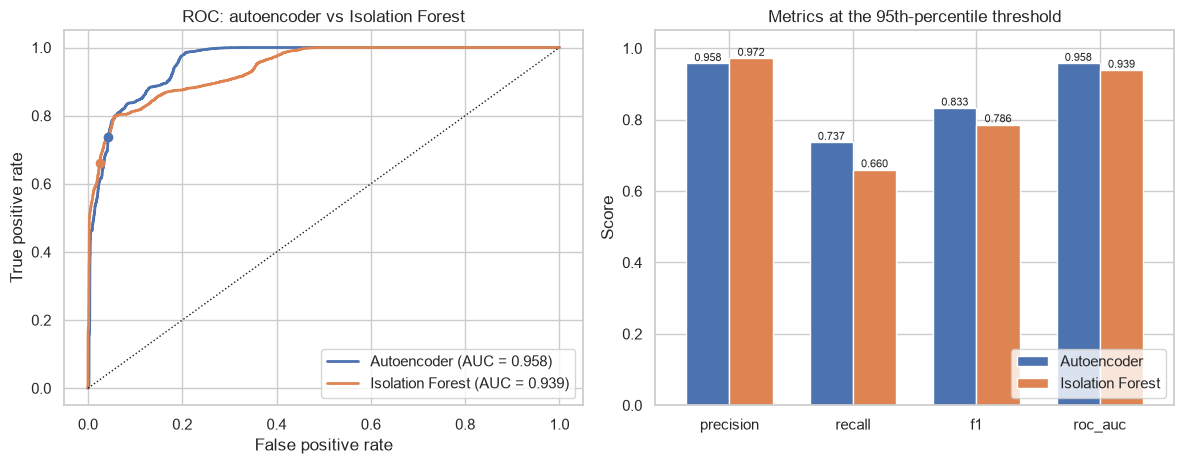

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for name, scores, s in [("Autoencoder", err_test, ae_summary), ("Isolation Forest", score_test_if, if_summary)]:
    f_, t_, _ = roc_curve(y_test, scores)
    axes[0].plot(f_, t_, lw=2, label=f"{name} (AUC = {s['roc_auc']:.3f})")
    axes[0].scatter([s["false_pos_rate"]], [s["recall"]], zorder=5)
axes[0].plot([0, 1], [0, 1], "k:", lw=1)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC: autoencoder vs Isolation Forest")
axes[0].legend(loc="lower right")

metrics = ["precision", "recall", "f1", "roc_auc"]
comparison[metrics].T.plot.bar(ax=axes[1], rot=0, width=0.7)
axes[1].set(ylim=(0, 1.05), ylabel="Score", title="Metrics at the 95th-percentile threshold")
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.3f", fontsize=8)
axes[1].legend(loc="lower right")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig4_model_comparison.png", dpi=200); plt.show()

The two detectors land at different false-positive rates (the same 95th-percentile rule produces
different test FPRs), so the operating-point metrics above are not a like-for-like comparison. The ROC curves
allow one: the table reads off each model's detection rate at the same fixed false-positive budgets.

In [18]:
def tpr_at_fpr(scores, budgets=(0.01, 0.025, 0.05, 0.10)):
    f_, t_, _ = roc_curve(y_test, scores)
    return [np.interp(b, f_, t_) for b in budgets]

matched = pd.DataFrame({"Autoencoder": tpr_at_fpr(err_test), "Isolation Forest": tpr_at_fpr(score_test_if)},
                       index=["recall @ 1% FPR", "recall @ 2.5% FPR", "recall @ 5% FPR", "recall @ 10% FPR"])
matched

,Autoencoder,Isolation Forest
recall @ 1% FPR,0.4813,0.5614
recall @ 2.5% FPR,0.6101,0.6627
recall @ 5% FPR,0.7796,0.7658
recall @ 10% FPR,0.8401,0.8138


### 3.5 Which attack types are detected best and worst?
Aggregate metrics hide the important part: an IDS that catches every DoS flood but misses every
privilege escalation is not a safe IDS. Recall (detection rate) is broken down by category and
by individual attack type.

In [19]:
res = pd.DataFrame({"label": test_df["label"], "category": cat_test, "novel": test_df["label"].isin(novel),
                    "ae": y_pred_ae, "iforest": y_pred_if, "err": err_test})

by_cat = (res.groupby("category")
             .agg(records=("ae", "size"), ae_detect=("ae", "mean"), if_detect=("iforest", "mean"),
                  median_error=("err", "median"))
             .reindex(["Normal", "DoS", "Probe", "R2L", "U2R"]))
by_cat = by_cat.rename(columns={"ae_detect": "AE flagged", "if_detect": "IForest flagged"})
print("Share of records flagged (for Normal this is the false-positive rate; for attacks it is recall)")
by_cat

Share of records flagged (for Normal this is the false-positive rate; for attacks it is recall)


,records,AE flagged,IForest flagged,median_error
category,,,,
Normal,9711,0.0430,0.0247,0.0138
DoS,7458,0.8555,0.8009,2.9219
Probe,2421,0.8137,0.9137,2.1766
R2L,2754,0.3522,0.0672,0.1801
U2R,200,0.6900,0.5000,0.6412


In [20]:
attacks = res[res["category"] != "Normal"]
by_type = (attacks.groupby(["label", "category"])
                  .agg(records=("ae", "size"), ae_recall=("ae", "mean"), if_recall=("iforest", "mean"),
                       novel=("novel", "first"))
                  .reset_index().sort_values("ae_recall", ascending=False))
print("Per-attack-type recall (types with >= 20 test records)")
by_type[by_type["records"] >= 20].reset_index(drop=True)

Per-attack-type recall (types with >= 20 test records)


,label,category,records,ae_recall,if_recall,novel
0,nmap,Probe,73,1.0000,1.0000,False
1,neptune,DoS,4657,0.9996,1.0000,False
2,apache2,DoS,737,0.9403,0.9267,True
3,back,DoS,359,0.9387,0.0000,False
4,portsweep,Probe,157,0.9299,0.9936,False
5,processtable,DoS,685,0.9109,0.8730,True
6,satan,Probe,735,0.9061,0.9959,False
7,buffer_overflow,U2R,20,0.8500,0.6500,False
8,mscan,Probe,996,0.7892,0.9779,True
9,warezmaster,R2L,944,0.7436,0.1716,False


In [21]:
seen_novel = (attacks.groupby("novel")[["ae", "iforest"]].mean()
                     .rename(index={False: "Attack type seen in training", True: "Novel attack type (test only)"},
                             columns={"ae": "AE recall", "iforest": "IForest recall"}))
seen_novel["records"] = attacks.groupby("novel").size().values
seen_novel

,AE recall,IForest recall,records
novel,,,
Attack type seen in training,0.7668,0.6476,9083
Novel attack type (test only),0.6648,0.6901,3750


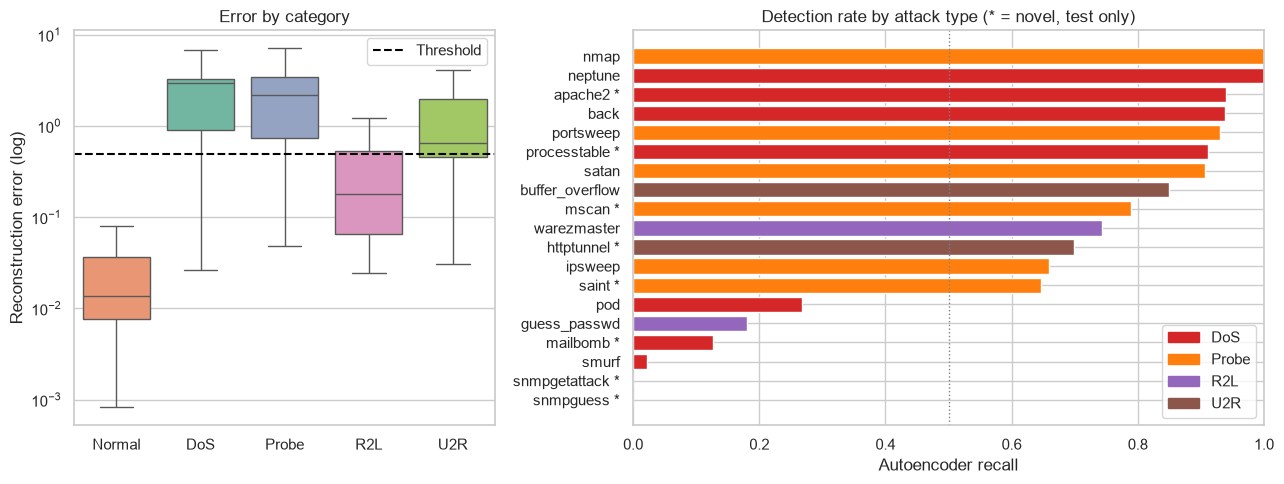

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 1.5]})
order = ["Normal", "DoS", "Probe", "R2L", "U2R"]
sns.boxplot(data=res, x="category", y="err", order=order, ax=axes[0], showfliers=False,
            hue="category", palette="Set2", legend=False)
axes[0].axhline(THRESHOLD, color="black", ls="--", label="Threshold")
axes[0].set(yscale="log", xlabel="", ylabel="Reconstruction error (log)", title="Error by category")
axes[0].legend()

plot_types = by_type[by_type["records"] >= 20].sort_values("ae_recall")
colors = plot_types["category"].map({"DoS": "tab:red", "Probe": "tab:orange", "R2L": "tab:purple", "U2R": "tab:brown"})
axes[1].barh(plot_types["label"] + np.where(plot_types["novel"], " *", ""), plot_types["ae_recall"], color=colors)
axes[1].axvline(0.5, color="grey", ls=":", lw=1)
axes[1].set(xlim=(0, 1), xlabel="Autoencoder recall", title="Detection rate by attack type (* = novel, test only)")
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=c, label=k) for k, c in
                        {"DoS": "tab:red", "Probe": "tab:orange", "R2L": "tab:purple", "U2R": "tab:brown"}.items()],
               loc="lower right")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig5_attack_type_recall.png", dpi=200); plt.show()

### 3.6 Why are some attacks invisible? Feature-level reconstruction error
The per-feature squared error shows *which* features the autoencoder fails to reconstruct for each
category, and so which behaviour gives an attack away.

In [23]:
sq_err = np.square(X_test - autoencoder.predict(X_test, batch_size=2048, verbose=0))
feat_err = pd.DataFrame(sq_err, columns=FEATURES).groupby(cat_test).mean().reindex(order)
top = {cat: ", ".join(f"{f} ({v:.1f})" for f, v in feat_err.loc[cat].nlargest(3).items()) for cat in order}
pd.DataFrame.from_dict(top, orient="index", columns=["Top-3 features by mean squared error"])

,Top-3 features by mean squared error
Normal,"root_shell (0.5), num_access_files (0.4), dst_host_diff_srv_rate (0.3)"
DoS,"same_srv_rate (18.3), src_bytes (8.3), count (7.1)"
Probe,"dst_host_srv_rerror_rate (11.6), srv_rerror_rate (10.0), rerror_rate (9.8)"
R2L,"num_access_files (3.4), hot (2.4), is_guest_login (1.7)"
U2R,"root_shell (43.6), num_access_files (29.3), is_host_login (17.6)"


### 3.7 Ablation: does the `log1p` step matter?
The same architecture and training settings, retrained on features scaled with StandardScaler only (no `log1p`),
to test the preprocessing decision in 1.4.

In [24]:
keras.utils.set_random_seed(SEED)
sc_raw = StandardScaler().fit(train_test_split(to_matrix(normal_train, log=False), test_size=0.20,
                                               random_state=SEED)[0])
Xn_raw = sc_raw.transform(to_matrix(normal_train, log=False)).astype("float32")
Xtr_r, Xva_r = train_test_split(Xn_raw, test_size=0.20, random_state=SEED)
Xte_r = sc_raw.transform(to_matrix(test_df, log=False)).astype("float32")

ae_raw = build_autoencoder(N_FEATURES)
ae_raw.fit(Xtr_r, Xtr_r, validation_data=(Xva_r, Xva_r), epochs=50, batch_size=256,
           callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
           verbose=0)
e_tr_r, e_te_r = reconstruction_error(ae_raw, Xtr_r), reconstruction_error(ae_raw, Xte_r)
raw_summary = summarise("Autoencoder, StandardScaler only", y_test,
                        (e_te_r > np.percentile(e_tr_r, 95)).astype(int), e_te_r)
ablation = pd.DataFrame([dict(ae_summary, model="Autoencoder, log1p + StandardScaler"), raw_summary]).set_index("model")
ablation[["precision", "recall", "f1", "false_pos_rate", "roc_auc"]]

,precision,recall,f1,false_pos_rate,roc_auc
model,,,,,
"Autoencoder, log1p + StandardScaler",0.9577,0.7370,0.8330,0.0430,0.9582
"Autoencoder, StandardScaler only",0.9576,0.7094,0.8150,0.0415,0.9359


## Findings

**1. The model trained properly on normal traffic only.** Training MSE fell from 0.786 to 0.135 over
50 epochs and validation MSE tracked it closely (0.530 → 0.136). The two curves converge with no
gap opening up, so the model is not over-fitting; validation loss was still improving slowly at
epoch 50, so early stopping never had to fire. The 95th-percentile threshold (MSE = 0.496) flagged
5.05% of *unseen* normal validation records, matching the intended 5% false-positive budget.

**2. Overall detection.** On the 22,544-record `KDDTest+` set the autoencoder reached **precision 0.958,
recall 0.737, F1 0.833 and ROC-AUC 0.958**, with a 4.3% false-positive rate. When it raises an alert it is
almost always right, but it misses about a quarter of attacks. The threshold table (3.3) shows the trade-off
a SOC would actually tune: the 90th percentile lifts recall to 0.806 (F1 0.870) at a 6.2% false-positive
rate, while the 99th percentile cuts false positives to 0.95% but catches fewer than half of attacks.

**3. Autoencoder vs Isolation Forest.** The autoencoder wins on the threshold-free measures (ROC-AUC 0.958 vs
0.939) and on F1 at the prescribed threshold (0.833 vs 0.786). The comparison is not one-sided, though.
At matched false-positive budgets Isolation Forest is better when alerts must be rare (56% vs 48% recall at
1% FPR), and the autoencoder pulls ahead from about 5% FPR upward (78% vs 77% at 5%, 84% vs 81% at 10%).
The bigger difference is *what* each model catches: the autoencoder detects 35% of R2L and 69% of U2R
attacks versus 7% and 50% for Isolation Forest, while Isolation Forest is better on Probe (91% vs 81%).
Tree-based isolation is good at points that are extreme on one or two features, which describes scans.
Reconstruction error also picks up unusual *combinations* of individually ordinary values, which is what
login and privilege attacks look like. The two are complementary, and an ensemble would be a natural next step.

**4. Best- and worst-detected attacks.**
- *Best:* high-volume, structurally abnormal traffic. `neptune` SYN floods (99.96%), `nmap` (100%),
  `back`, `portsweep`, `satan` and the novel `apache2` and `processtable` attacks (> 90%). Their errors sit
  one to two orders of magnitude above normal traffic, driven by `same_srv_rate`, `count` and the error-rate features.
- *Worst:* R2L is the hardest category (35% recall). `snmpgetattack` and `snmpguess` are never detected; in fact
  30% of `snmpgetattack` records have numerical feature vectors *identical* to normal test records, so no model of these
  features could separate them. `guess_passwd` (18%) is hard because only 38% of its records even
  record a failed login. Each password guess is an ordinary-looking short session, and the attack only shows up across many sessions.
- *A cost of the numerical-only design:* `smurf` (2%) and `mailbomb` (13%) are DoS attacks the model misses.
  A smurf packet carries about 1,008 bytes where a normal ICMP echo carries about 30, but once `protocol_type` and `service` are
  dropped, 1,008 bytes looks like a normal connection. These anomalies depend on *context*, and removing the categorical
  features removed that context. One-hot encoding them is the clearest improvement for a future version.
- *U2R:* surprisingly good (69%), because `root_shell` and `num_access_files` are almost always zero in normal
  traffic and so produce very large reconstruction errors. With 200 test records, this estimate is noisy.

**5. Generalisation to unseen attacks.** On the 17 attack types that appear only in the test set, the
autoencoder still caught 66.5% (vs 76.7% on types seen in the training data's attack labels, which it never used). That is the
case for anomaly detection: a signature system would catch 0% of attacks it has no signature for.

**6. Preprocessing matters.** The ablation (3.7) shows that the `log1p` step before StandardScaler raised ROC-AUC from 0.936 to 0.958
and recall from 0.709 to 0.737 at a similar false-positive rate, so the choice of normalisation is part of the detector's accuracy.

**Limitations.** NSL-KDD is derived from 1998 traffic and is well known to be dated. The results come from a single seed, and the
threshold is fixed by policy rather than tuned. The per-record features also cannot see behaviour that spans many connections,
such as slow brute force or low-rate floods.

**References.** Tavallaee, M., Bagheri, E., Lu, W., & Ghorbani, A. A. (2009). A detailed analysis of the KDD CUP 99 data set.
*IEEE Symposium on Computational Intelligence for Security and Defense Applications*, 1–6. ·
Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation forest. *IEEE International Conference on Data Mining*, 413–422.